In [ ]:
# ============================================================
# CELL 1 — IMPORTS + PATHS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

PROJECT_ROOT = Path("..").resolve()

POSITIVE_ROOT = PROJECT_ROOT / "data" / "center_detection_v1"
COMBINED_ROOT = PROJECT_ROOT / "data" / "center_detection_v2"
MODEL_ROOT = PROJECT_ROOT / "models"
RESULTS_ROOT = PROJECT_ROOT / "results"

FINAL_MODEL_PATH = MODEL_ROOT / "center_detection_experiment_03_final.pt"
TEST_PREDICTIONS_PATH = RESULTS_ROOT / "test_predictions.csv"
COMBINED_MANIFEST_PATH = COMBINED_ROOT / "combined_manifest.csv"

# Optional raw-data paths for deeper diagnostics only.
IBTRACS_PATH = Path(r"PATH_TO_IBTRACS/ibtracs_all_list_v04r01.csv")
ERA5_SINGLE_LEVEL_PATH = Path(r"PATH_TO_ERA5/era5_single_2023_01.nc")

In [3]:
# ============================================================
# CELL 2 — LOAD SAVED ANALYSIS DATA
# ============================================================

test_predictions = pd.read_csv(
    TEST_PREDICTIONS_PATH
)

test_predictions["timestamp"] = pd.to_datetime(
    test_predictions["timestamp"],
    format="mixed",
    utc=True,
)


manifest = pd.read_csv(
    COMBINED_MANIFEST_PATH
)

manifest["timestamp"] = pd.to_datetime(
    manifest["timestamp"],
    format="mixed",
    utc=True,
)


latitude = np.load(
    POSITIVE_ROOT
    / "latitude.npy"
)

longitude = np.load(
    POSITIVE_ROOT
    / "longitude.npy"
)


print("=" * 72)
print("ERROR ANALYSIS DATA")
print("=" * 72)

print(
    "Test predictions:",
    len(test_predictions)
)

print(
    "Combined manifest:",
    len(manifest)
)

print(
    "Latitude:",
    latitude.shape
)

print(
    "Longitude:",
    longitude.shape
)

ERROR ANALYSIS DATA
Test predictions: 682
Combined manifest: 3800
Latitude: (121,)
Longitude: (121,)


In [4]:
# ============================================================
# CELL 3 — FAILURE GROUPS
# ============================================================

false_negatives = (
    test_predictions[
        (test_predictions["actual_presence"] == 1)
        &
        (test_predictions["predicted_presence"] == 0)
    ]
    .copy()
    .sort_values(
        "presence_probability"
    )
)


false_positives = (
    test_predictions[
        (test_predictions["actual_presence"] == 0)
        &
        (test_predictions["predicted_presence"] == 1)
    ]
    .copy()
    .sort_values(
        "presence_probability",
        ascending=False,
    )
)


detected_cyclones = (
    test_predictions[
        (test_predictions["actual_presence"] == 1)
        &
        (test_predictions["predicted_presence"] == 1)
    ]
    .copy()
)


worst_localization = (
    detected_cyclones
    .sort_values(
        "localization_error_km",
        ascending=False,
    )
)


print("=" * 72)
print("FAILURE GROUPS")
print("=" * 72)

print(
    "False negatives:",
    len(false_negatives)
)

print(
    "False positives:",
    len(false_positives)
)

print(
    "Detected cyclones:",
    len(detected_cyclones)
)

print()

print(
    "Worst localization error:",
    worst_localization[
        "localization_error_km"
    ].max()
)

FAILURE GROUPS
False negatives: 20
False positives: 20
Detected cyclones: 321

Worst localization error: 224.0683628721965


In [5]:
# ============================================================
# CELL 4 — LOAD REGIONAL IBTRACS
# ============================================================

ibtracs = pd.read_csv(
    IBTRACS_PATH,
    low_memory=False,
)


ibtracs["ISO_TIME"] = pd.to_datetime(
    ibtracs["ISO_TIME"],
    format="mixed",
    utc=True,
    errors="coerce",
)

ibtracs["LAT"] = pd.to_numeric(
    ibtracs["LAT"],
    errors="coerce",
)

ibtracs["LON"] = pd.to_numeric(
    ibtracs["LON"],
    errors="coerce",
)


ibtracs = ibtracs.dropna(
    subset=[
        "SID",
        "ISO_TIME",
        "LAT",
        "LON",
    ]
).copy()


regional_ibtracs = ibtracs[
    (ibtracs["ISO_TIME"].dt.year >= 2000)
    &
    (ibtracs["ISO_TIME"].dt.year <= 2025)

    &
    (ibtracs["LAT"] >= 0.0)
    &
    (ibtracs["LAT"] <= 30.0)

    &
    (ibtracs["LON"] >= 75.0)
    &
    (ibtracs["LON"] <= 105.0)

    &
    (
        ibtracs["ISO_TIME"]
        .dt.hour
        .isin(
            [0, 6, 12, 18]
        )
    )

    &
    (
        ibtracs["ISO_TIME"]
        .dt.minute
        ==
        0
    )
].copy()


regional_ibtracs = (
    regional_ibtracs
    .sort_values(
        [
            "SID",
            "ISO_TIME",
        ]
    )
    .reset_index(drop=True)
)


print("=" * 72)
print("REGIONAL IBTRACS")
print("=" * 72)

print(
    "Rows:",
    len(regional_ibtracs)
)

print(
    "Cyclones:",
    regional_ibtracs[
        "SID"
    ].nunique()
)

print(
    "Unique timestamps:",
    regional_ibtracs[
        "ISO_TIME"
    ].nunique()
)

print(
    "Start:",
    regional_ibtracs[
        "ISO_TIME"
    ].min()
)

print(
    "End:",
    regional_ibtracs[
        "ISO_TIME"
    ].max()
)

REGIONAL IBTRACS
Rows: 3131
Cyclones: 269
Unique timestamps: 3073
Start: 2000-03-27 12:00:00+00:00
End: 2025-12-02 12:00:00+00:00


In [ ]:
# ============================================================
# CELL 5 — FALSE POSITIVE TEMPORAL AUDIT
# ============================================================

audit_rows = []


for _, fp in false_positives.iterrows():

    fp_time = pd.Timestamp(
        fp["timestamp"]
    )

    delta_hours = (
        (
            regional_ibtracs["ISO_TIME"]
            -
            fp_time
        )
        .dt.total_seconds()
        /
        3600.0
    )

    nearest_idx = (
        delta_hours
        .abs()
        .idxmin()
    )

    nearest = (
        regional_ibtracs.loc[
            nearest_idx
        ]
    )

    signed_hours = float(
        delta_hours.loc[
            nearest_idx
        ]
    )

    audit_rows.append(
        {
            "sample_id":
                fp["sample_id"],

            "timestamp":
                fp_time,

            "presence_probability":
                float(
                    fp["presence_probability"]
                ),

            "pred_lat":
                float(
                    fp["pred_lat"]
                ),

            "pred_lon":
                float(
                    fp["pred_lon"]
                ),

            "nearest_sid":
                nearest["SID"],

            "nearest_name":
                nearest["NAME"]
                if "NAME" in nearest.index
                else "UNKNOWN",

            "nearest_time":
                nearest["ISO_TIME"],

            "time_difference_hours":
                signed_hours,

            "absolute_time_difference_hours":
                abs(signed_hours),

            "ibtracs_lat":
                float(
                    nearest["LAT"]
                ),

            "ibtracs_lon":
                float(
                    nearest["LON"]
                ),
        }
    )


false_positive_audit = pd.DataFrame(
    audit_rows
)


false_positive_audit = (
    false_positive_audit
    .sort_values(
        "presence_probability",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(
    false_positive_audit
)

,sample_id,timestamp,presence_probability,pred_lat,pred_lon,nearest_sid,nearest_name,nearest_time,time_difference_hours,absolute_time_difference_hours,ibtracs_lat,ibtracs_lon
0,negative_000113,2023-01-28 06:00:00+00:00,0.981402,6.00,90.75,2023030N08087,UNKNOWN,2023-01-30 06:00:00+00:00,48.0,48.0,7.9,86.6
1,negative_000296,2024-12-24 00:00:00+00:00,0.964776,11.50,83.25,2024356N14084,UNKNOWN,2024-12-21 06:00:00+00:00,-66.0,66.0,14.1,84.6
2,negative_000295,2024-12-22 12:00:00+00:00,0.954491,13.25,85.50,2024356N14084,UNKNOWN,2024-12-21 06:00:00+00:00,-30.0,30.0,14.1,84.6
3,negative_000071,2022-11-11 06:00:00+00:00,0.933709,9.50,81.50,2022324N10086,UNKNOWN,2022-11-20 00:00:00+00:00,210.0,210.0,10.0,85.5
4,negative_000070,2022-11-10 18:00:00+00:00,0.927378,9.25,84.00,2022324N10086,UNKNOWN,2022-11-20 00:00:00+00:00,222.0,222.0,10.0,85.5
5,negative_000112,2023-01-27 18:00:00+00:00,0.902165,4.25,91.25,2023030N08087,UNKNOWN,2023-01-30 06:00:00+00:00,60.0,60.0,7.9,86.6
6,negative_000069,2022-11-10 00:00:00+00:00,0.834571,7.25,85.00,2022324N10086,UNKNOWN,2022-11-20 00:00:00+00:00,240.0,240.0,10.0,85.5
7,negative_000315,2025-11-03 00:00:00+00:00,0.829421,17.75,94.25,2025305N08140,UNKNOWN,2025-11-07 12:00:00+00:00,108.0,108.0,15.4,104.3
8,negative_000312,2025-10-22 06:00:00+00:00,0.821767,12.00,80.00,2025300N11086,UNKNOWN,2025-10-26 12:00:00+00:00,102.0,102.0,11.3,86.1
9,negative_000294,2024-12-17 00:00:00+00:00,0.808741,10.50,82.00,2024356N14084,UNKNOWN,2024-12-20 12:00:00+00:00,84.0,84.0,13.7,83.5


In [7]:
# ============================================================
# CELL 6 — FALSE POSITIVE TEMPORAL DISTANCE DISTRIBUTION
# ============================================================

bins = [
    24,
    48,
    72,
    120,
    168,
    np.inf,
]

labels = [
    "24–48 h",
    "48–72 h",
    "72–120 h",
    "120–168 h",
    ">168 h",
]


false_positive_audit[
    "time_bin"
] = pd.cut(
    false_positive_audit[
        "absolute_time_difference_hours"
    ],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=False,
)


time_bin_summary = (
    false_positive_audit[
        "time_bin"
    ]
    .value_counts(
        sort=False
    )
    .rename(
        "count"
    )
    .reset_index()
)


time_bin_summary[
    "percent"
] = (
    time_bin_summary["count"]
    /
    len(false_positive_audit)
    *
    100.0
)


display(
    time_bin_summary
)

,time_bin,count,percent
0,24–48 h,6,30.0
1,48–72 h,2,10.0
2,72–120 h,7,35.0
3,120–168 h,1,5.0
4,>168 h,4,20.0


In [8]:
# ============================================================
# CELL 7 — SPATIAL DISTANCE TO NEAREST IBTRACS OBSERVATION
# ============================================================

def haversine_km(
    lat1,
    lon1,
    lat2,
    lon2,
):

    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(
            dlat / 2.0
        ) ** 2
        +
        np.cos(lat1)
        *
        np.cos(lat2)
        *
        np.sin(
            dlon / 2.0
        ) ** 2
    )

    return (
        2.0
        *
        R
        *
        np.arcsin(
            np.sqrt(a)
        )
    )


false_positive_audit[
    "distance_to_nearest_track_km"
] = haversine_km(
    false_positive_audit[
        "pred_lat"
    ].to_numpy(),

    false_positive_audit[
        "pred_lon"
    ].to_numpy(),

    false_positive_audit[
        "ibtracs_lat"
    ].to_numpy(),

    false_positive_audit[
        "ibtracs_lon"
    ].to_numpy(),
)


display(
    false_positive_audit[
        [
            "sample_id",
            "presence_probability",
            "absolute_time_difference_hours",
            "pred_lat",
            "pred_lon",
            "ibtracs_lat",
            "ibtracs_lon",
            "distance_to_nearest_track_km",
        ]
    ].round(2)
)

,sample_id,presence_probability,absolute_time_difference_hours,pred_lat,pred_lon,ibtracs_lat,ibtracs_lon,distance_to_nearest_track_km
0,negative_000113,0.98,48.0,6.00,90.75,7.9,86.6,504.42
1,negative_000296,0.96,66.0,11.50,83.25,14.1,84.6,324.05
2,negative_000295,0.95,30.0,13.25,85.50,14.1,84.6,135.60
3,negative_000071,0.93,210.0,9.50,81.50,10.0,85.5,441.86
4,negative_000070,0.93,222.0,9.25,84.00,10.0,85.5,184.38
5,negative_000112,0.90,60.0,4.25,91.25,7.9,86.6,654.97
6,negative_000069,0.83,240.0,7.25,85.00,10.0,85.5,310.69
7,negative_000315,0.83,108.0,17.75,94.25,15.4,104.3,1102.29
8,negative_000312,0.82,102.0,12.00,80.00,11.3,86.1,668.84
9,negative_000294,0.81,84.0,10.50,82.00,13.7,83.5,391.41


In [9]:
# ============================================================
# CELL 8 — FALSE POSITIVE SUMMARY
# ============================================================

fp_summary = pd.DataFrame(
    {
        "metric": [
            "False positives",
            "Median cyclone probability",
            "Within 48 h of IBTrACS",
            "Within 72 h of IBTrACS",
            "Within 120 h of IBTrACS",
            "Median temporal distance (h)",
            "Median spatial distance (km)",
        ],

        "value": [
            len(false_positive_audit),

            false_positive_audit[
                "presence_probability"
            ].median(),

            np.mean(
                false_positive_audit[
                    "absolute_time_difference_hours"
                ] <= 48
            ),

            np.mean(
                false_positive_audit[
                    "absolute_time_difference_hours"
                ] <= 72
            ),

            np.mean(
                false_positive_audit[
                    "absolute_time_difference_hours"
                ] <= 120
            ),

            false_positive_audit[
                "absolute_time_difference_hours"
            ].median(),

            false_positive_audit[
                "distance_to_nearest_track_km"
            ].median(),
        ],
    }
)


display(
    fp_summary
)

,metric,value
0,False positives,20.000000
1,Median cyclone probability,0.800001
2,Within 48 h of IBTrACS,0.300000
3,Within 72 h of IBTrACS,0.400000
4,Within 120 h of IBTrACS,0.750000
5,Median temporal distance (h),93.000000
6,Median spatial distance (km),661.905257


In [ ]:
# ============================================================
# CELL 9 — DISTANCE TO NEAREST CYCLONE'S FULL TRACK
# ============================================================

track_audit_rows = []


for _, fp in false_positive_audit.iterrows():

    sid = fp["nearest_sid"]

    track = regional_ibtracs[
        regional_ibtracs["SID"] == sid
    ].copy()

    distances = haversine_km(
        fp["pred_lat"],
        fp["pred_lon"],
        track["LAT"].to_numpy(),
        track["LON"].to_numpy(),
    )

    min_idx = np.argmin(
        distances
    )

    closest_track_point = (
        track.iloc[min_idx]
    )

    min_distance = float(
        distances[min_idx]
    )

    time_to_closest_point = abs(
        (
            closest_track_point["ISO_TIME"]
            -
            fp["timestamp"]
        ).total_seconds()
        /
        3600.0
    )

    track_audit_rows.append(
        {
            "sample_id":
                fp["sample_id"],

            "presence_probability":
                fp["presence_probability"],

            "nearest_sid":
                sid,

            "pred_lat":
                fp["pred_lat"],

            "pred_lon":
                fp["pred_lon"],

            "nearest_temporal_hours":
                fp["absolute_time_difference_hours"],

            "min_track_distance_km":
                min_distance,

            "closest_track_time":
                closest_track_point["ISO_TIME"],

            "time_to_closest_track_point_h":
                time_to_closest_point,

            "closest_track_lat":
                closest_track_point["LAT"],

            "closest_track_lon":
                closest_track_point["LON"],
        }
    )


fp_track_audit = pd.DataFrame(
    track_audit_rows
)


display(
    fp_track_audit.round(2)
)

C:\Users\USER\AppData\Local\Temp\ipykernel_13984\960294441.py:95: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  fp_track_audit.round(2)


,sample_id,presence_probability,nearest_sid,pred_lat,pred_lon,nearest_temporal_hours,min_track_distance_km,closest_track_time,time_to_closest_track_point_h,closest_track_lat,closest_track_lon
0,negative_000113,0.98,2023030N08087,6.00,90.75,48.0,504.42,2023-01-30 06:00:00+00:00,48.0,7.9,86.6
1,negative_000296,0.96,2024356N14084,11.50,83.25,66.0,246.13,2024-12-20 12:00:00+00:00,84.0,13.7,83.5
2,negative_000295,0.95,2024356N14084,13.25,85.50,30.0,135.60,2024-12-21 06:00:00+00:00,30.0,14.1,84.6
3,negative_000071,0.93,2022324N10086,9.50,81.50,210.0,381.98,2022-11-21 12:00:00+00:00,246.0,12.9,82.0
4,negative_000070,0.93,2022324N10086,9.25,84.00,222.0,184.19,2022-11-20 06:00:00+00:00,228.0,10.3,85.3
5,negative_000112,0.90,2023030N08087,4.25,91.25,60.0,654.97,2023-01-30 06:00:00+00:00,60.0,7.9,86.6
6,negative_000069,0.83,2022324N10086,7.25,85.00,240.0,310.69,2022-11-20 00:00:00+00:00,240.0,10.0,85.5
7,negative_000315,0.83,2025305N08140,17.75,94.25,108.0,969.48,2025-11-07 18:00:00+00:00,114.0,16.1,103.2
8,negative_000312,0.82,2025300N11086,12.00,80.00,102.0,435.70,2025-10-28 00:00:00+00:00,138.0,14.5,83.1
9,negative_000294,0.81,2024356N14084,10.50,82.00,84.0,391.41,2024-12-20 12:00:00+00:00,84.0,13.7,83.5


In [11]:
# ============================================================
# CELL 10 — TRACK PROXIMITY SUMMARY
# ============================================================

print("=" * 72)
print("FALSE POSITIVE — CYCLONE TRACK PROXIMITY")
print("=" * 72)

print(
    "Median minimum track distance:",
    round(
        fp_track_audit[
            "min_track_distance_km"
        ].median(),
        1,
    ),
    "km"
)

print()

for threshold in [
    100,
    200,
    300,
    500,
]:

    n = (
        fp_track_audit[
            "min_track_distance_km"
        ]
        <= threshold
    ).sum()

    print(
        f"Within {threshold:3d} km of track: "
        f"{n:2d}/{len(fp_track_audit)} "
        f"({100*n/len(fp_track_audit):.1f}%)"
    )

FALSE POSITIVE — CYCLONE TRACK PROXIMITY
Median minimum track distance: 470.1 km

Within 100 km of track:  0/20 (0.0%)
Within 200 km of track:  3/20 (15.0%)
Within 300 km of track:  5/20 (25.0%)
Within 500 km of track: 10/20 (50.0%)


In [12]:
# ============================================================
# CELL 11 — COMBINED TEMPORAL + SPATIAL AUDIT
# ============================================================

combined_fp_audit = (
    fp_track_audit.copy()
)


# ------------------------------------------------------------
# Define exploratory compatibility criteria
#
# These are NOT cyclone-definition thresholds.
# They are only used to select cases for manual inspection.
# ------------------------------------------------------------

combined_fp_audit[
    "within_120h"
] = (
    combined_fp_audit[
        "nearest_temporal_hours"
    ]
    <= 120
)


combined_fp_audit[
    "within_300km_track"
] = (
    combined_fp_audit[
        "min_track_distance_km"
    ]
    <= 300
)


combined_fp_audit[
    "candidate_related_system"
] = (
    combined_fp_audit["within_120h"]
    &
    combined_fp_audit["within_300km_track"]
)


# ------------------------------------------------------------
# Sort most interesting cases first
# ------------------------------------------------------------

combined_fp_audit = (
    combined_fp_audit
    .sort_values(
        [
            "candidate_related_system",
            "nearest_temporal_hours",
            "min_track_distance_km",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)


display(
    combined_fp_audit[
        [
            "sample_id",
            "presence_probability",
            "nearest_sid",
            "nearest_temporal_hours",
            "min_track_distance_km",
            "time_to_closest_track_point_h",
            "candidate_related_system",
        ]
    ].round(2)
)

,sample_id,presence_probability,nearest_sid,nearest_temporal_hours,min_track_distance_km,time_to_closest_track_point_h,candidate_related_system
0,negative_000295,0.95,2024356N14084,30.0,135.60,30.0,True
1,negative_000296,0.96,2024356N14084,66.0,246.13,84.0,True
2,negative_000088,0.60,2022338N05100,84.0,145.82,198.0,True
3,negative_000303,0.75,2025274N16087,36.0,643.40,36.0,False
4,negative_000323,0.57,2025330N05099,36.0,1568.64,48.0,False
5,negative_000264,0.73,2024244N09137,42.0,1189.65,78.0,False
6,negative_000095,0.79,2022356N09085,48.0,390.05,48.0,False
7,negative_000113,0.98,2023030N08087,48.0,504.42,48.0,False
8,negative_000112,0.90,2023030N08087,60.0,654.97,60.0,False
9,negative_000294,0.81,2024356N14084,84.0,391.41,84.0,False


In [13]:
# ============================================================
# CELL 12 — COMBINED AUDIT SUMMARY
# ============================================================

n_total = len(
    combined_fp_audit
)

n_temporal = (
    combined_fp_audit[
        "within_120h"
    ].sum()
)

n_spatial = (
    combined_fp_audit[
        "within_300km_track"
    ].sum()
)

n_combined = (
    combined_fp_audit[
        "candidate_related_system"
    ].sum()
)


print("=" * 72)
print("FALSE POSITIVE — COMBINED AUDIT")
print("=" * 72)

print(
    f"Total false positives:             {n_total}"
)

print(
    f"Within 120 h of IBTrACS:           "
    f"{n_temporal}/{n_total} "
    f"({100*n_temporal/n_total:.1f}%)"
)

print(
    f"Within 300 km of associated track: "
    f"{n_spatial}/{n_total} "
    f"({100*n_spatial/n_total:.1f}%)"
)

print(
    f"Meeting both criteria:             "
    f"{n_combined}/{n_total} "
    f"({100*n_combined/n_total:.1f}%)"
)

FALSE POSITIVE — COMBINED AUDIT
Total false positives:             20
Within 120 h of IBTrACS:           15/20 (75.0%)
Within 300 km of associated track: 5/20 (25.0%)
Meeting both criteria:             3/20 (15.0%)


In [14]:
# ============================================================
# CELL 13 — CANDIDATE CYCLONE-RELATED FALSE POSITIVES
# ============================================================

candidate_fp = (
    combined_fp_audit[
        combined_fp_audit[
            "candidate_related_system"
        ]
    ]
    .copy()
    .sort_values(
        [
            "nearest_temporal_hours",
            "min_track_distance_km",
        ]
    )
    .reset_index(drop=True)
)


print("=" * 72)
print("CANDIDATE CYCLONE-RELATED FALSE POSITIVES")
print("=" * 72)

print(
    "Cases:",
    len(candidate_fp)
)

print()


display(
    candidate_fp[
        [
            "sample_id",
            "presence_probability",
            "nearest_sid",
            "nearest_temporal_hours",
            "min_track_distance_km",
            "closest_track_time",
            "time_to_closest_track_point_h",
            "pred_lat",
            "pred_lon",
            "closest_track_lat",
            "closest_track_lon",
        ]
    ].round(2)
)

CANDIDATE CYCLONE-RELATED FALSE POSITIVES
Cases: 3



C:\Users\USER\AppData\Local\Temp\ipykernel_13984\226270567.py:49: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


,sample_id,presence_probability,nearest_sid,nearest_temporal_hours,min_track_distance_km,closest_track_time,time_to_closest_track_point_h,pred_lat,pred_lon,closest_track_lat,closest_track_lon
0,negative_000295,0.95,2024356N14084,30.0,135.60,2024-12-21 06:00:00+00:00,30.0,13.25,85.50,14.1,84.6
1,negative_000296,0.96,2024356N14084,66.0,246.13,2024-12-20 12:00:00+00:00,84.0,11.50,83.25,13.7,83.5
2,negative_000088,0.60,2022338N05100,84.0,145.82,2022-12-05 18:00:00+00:00,198.0,6.75,92.00,8.0,91.6


In [ ]:
# ============================================================
# CELL 14 — JOINT SPACE-TIME IBTRACS SEARCH
# ============================================================

joint_rows = []


for _, fp in false_positives.iterrows():

    fp_time = pd.Timestamp(
        fp["timestamp"]
    )

    # --------------------------------------------------------
    # All IBTrACS observations within ±120 hours
    # --------------------------------------------------------

    delta_hours = (
        (
            regional_ibtracs["ISO_TIME"]
            -
            fp_time
        )
        .dt.total_seconds()
        /
        3600.0
    )

    nearby = regional_ibtracs[
        delta_hours.abs() <= 120
    ].copy()

    nearby[
        "time_difference_hours"
    ] = delta_hours.loc[
        nearby.index
    ].to_numpy()

    # --------------------------------------------------------
    # No nearby cyclone observation
    # --------------------------------------------------------

    if len(nearby) == 0:

        joint_rows.append(
            {
                "sample_id":
                    fp["sample_id"],

                "presence_probability":
                    fp["presence_probability"],

                "matched_sid":
                    None,

                "matched_time":
                    pd.NaT,

                "time_difference_hours":
                    np.nan,

                "spatial_distance_km":
                    np.nan,

                "matched_lat":
                    np.nan,

                "matched_lon":
                    np.nan,
            }
        )

        continue

    # --------------------------------------------------------
    # Distance from CNN center to every nearby track point
    # --------------------------------------------------------

    distances = haversine_km(
        float(fp["pred_lat"]),
        float(fp["pred_lon"]),
        nearby["LAT"].to_numpy(),
        nearby["LON"].to_numpy(),
    )

    best_position = int(
        np.argmin(distances)
    )

    best = nearby.iloc[
        best_position
    ]

    joint_rows.append(
        {
            "sample_id":
                fp["sample_id"],

            "presence_probability":
                float(
                    fp["presence_probability"]
                ),

            "pred_lat":
                float(fp["pred_lat"]),

            "pred_lon":
                float(fp["pred_lon"]),

            "matched_sid":
                best["SID"],

            "matched_time":
                best["ISO_TIME"],

            "time_difference_hours":
                float(
                    best[
                        "time_difference_hours"
                    ]
                ),

            "spatial_distance_km":
                float(
                    distances[
                        best_position
                    ]
                ),

            "matched_lat":
                float(best["LAT"]),

            "matched_lon":
                float(best["LON"]),
        }
    )


joint_fp_audit = pd.DataFrame(
    joint_rows
)


joint_fp_audit[
    "absolute_time_hours"
] = (
    joint_fp_audit[
        "time_difference_hours"
    ].abs()
)


joint_fp_audit[
    "candidate"
] = (
    (
        joint_fp_audit[
            "absolute_time_hours"
        ]
        <= 120
    )
    &
    (
        joint_fp_audit[
            "spatial_distance_km"
        ]
        <= 300
    )
)


joint_fp_audit = (
    joint_fp_audit
    .sort_values(
        [
            "candidate",
            "spatial_distance_km",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)


display(
    joint_fp_audit.round(2)
)

C:\Users\USER\AppData\Local\Temp\ipykernel_13984\3217374317.py:195: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  joint_fp_audit.round(2)


,sample_id,presence_probability,pred_lat,pred_lon,matched_sid,matched_time,time_difference_hours,spatial_distance_km,matched_lat,matched_lon,absolute_time_hours,candidate
0,negative_000295,0.95,13.25,85.50,2024356N14084,2024-12-21 06:00:00+00:00,-30.0,135.60,14.1,84.6,30.0,True
1,negative_000296,0.96,11.50,83.25,2024356N14084,2024-12-20 12:00:00+00:00,-84.0,246.13,13.7,83.5,84.0,True
2,negative_000323,0.57,5.25,83.75,2025331N07081,2025-11-27 06:00:00+00:00,78.0,266.72,7.0,82.1,78.0,True
3,negative_000264,0.73,17.50,90.25,2024252N18087,2024-09-08 00:00:00+00:00,42.0,347.13,17.9,87.0,42.0,False
4,negative_000095,0.79,6.75,87.00,2022356N09085,2022-12-22 06:00:00+00:00,48.0,390.05,9.5,84.8,48.0,False
5,negative_000294,0.81,10.50,82.00,2024356N14084,2024-12-20 12:00:00+00:00,84.0,391.41,13.7,83.5,84.0,False
6,negative_000312,0.82,12.00,80.00,2025300N11086,2025-10-27 06:00:00+00:00,120.0,473.51,12.7,84.3,120.0,False
7,negative_000113,0.98,6.00,90.75,2023030N08087,2023-01-30 06:00:00+00:00,48.0,504.42,7.9,86.6,48.0,False
8,negative_000303,0.75,25.25,84.00,2025274N16087,2025-10-02 12:00:00+00:00,-36.0,643.40,19.5,84.7,36.0,False
9,negative_000112,0.90,4.25,91.25,2023030N08087,2023-01-30 06:00:00+00:00,60.0,654.97,7.9,86.6,60.0,False


In [16]:
# ============================================================
# CELL 15 — JOINT SPACE-TIME SCREENING SUMMARY
# ============================================================

candidate_joint = (
    joint_fp_audit[
        joint_fp_audit["candidate"]
    ]
    .copy()
)


print("=" * 72)
print("JOINT SPACE-TIME FALSE-POSITIVE SCREENING")
print("=" * 72)

print(
    f"False positives: {len(joint_fp_audit)}"
)

print(
    f"IBTrACS observation within ±120 h: "
    f"{joint_fp_audit['matched_sid'].notna().sum()}"
)

print(
    f"Within ±120 h AND ≤300 km: "
    f"{len(candidate_joint)}"
)

print()


display(
    candidate_joint[
        [
            "sample_id",
            "presence_probability",
            "matched_sid",
            "time_difference_hours",
            "spatial_distance_km",
            "pred_lat",
            "pred_lon",
            "matched_lat",
            "matched_lon",
        ]
    ].round(2)
)

JOINT SPACE-TIME FALSE-POSITIVE SCREENING
False positives: 20
IBTrACS observation within ±120 h: 15
Within ±120 h AND ≤300 km: 3



,sample_id,presence_probability,matched_sid,time_difference_hours,spatial_distance_km,pred_lat,pred_lon,matched_lat,matched_lon
0,negative_000295,0.95,2024356N14084,-30.0,135.60,13.25,85.50,14.1,84.6
1,negative_000296,0.96,2024356N14084,-84.0,246.13,11.50,83.25,13.7,83.5
2,negative_000323,0.57,2025331N07081,78.0,266.72,5.25,83.75,7.0,82.1


In [17]:
# ============================================================
# CELL 16 — FALSE NEGATIVE ANALYSIS
# ============================================================

print("=" * 72)
print("FALSE NEGATIVE ANALYSIS")
print("=" * 72)

print(
    "False negatives:",
    len(false_negatives)
)

print()

print(
    false_negatives[
        "presence_probability"
    ].describe()
)

print()


# ------------------------------------------------------------
# Confidence groups
# ------------------------------------------------------------

very_confident_miss = (
    false_negatives[
        false_negatives[
            "presence_probability"
        ] < 0.10
    ]
)

moderate_miss = (
    false_negatives[
        (
            false_negatives[
                "presence_probability"
            ] >= 0.10
        )
        &
        (
            false_negatives[
                "presence_probability"
            ] < 0.30
        )
    ]
)

borderline_miss = (
    false_negatives[
        false_negatives[
            "presence_probability"
        ] >= 0.30
    ]
)


print(
    "Very confident misses (p < 0.10):",
    len(very_confident_miss)
)

print(
    "Moderate misses (0.10 ≤ p < 0.30):",
    len(moderate_miss)
)

print(
    "Borderline misses (0.30 ≤ p < 0.50):",
    len(borderline_miss)
)

FALSE NEGATIVE ANALYSIS
False negatives: 20

count    20.000000
mean      0.142439
std       0.154626
min       0.012738
25%       0.032713
50%       0.055655
75%       0.280373
max       0.482532
Name: presence_probability, dtype: float64

Very confident misses (p < 0.10): 13
Moderate misses (0.10 ≤ p < 0.30): 2
Borderline misses (0.30 ≤ p < 0.50): 5


In [18]:
# ============================================================
# CELL 17 — FALSE NEGATIVE CASE TABLE
# ============================================================

fn_table = (
    false_negatives[
        [
            "sample_id",
            "timestamp",
            "presence_probability",
            "true_lat",
            "true_lon",
            "pred_lat",
            "pred_lon",
            "localization_error_km",
        ]
    ]
    .copy()
    .sort_values(
        "presence_probability"
    )
    .reset_index(drop=True)
)


display(
    fn_table.round(3)
)

C:\Users\USER\AppData\Local\Temp\ipykernel_13984\3544762534.py:27: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  fn_table.round(3)


,sample_id,timestamp,presence_probability,true_lat,true_lon,pred_lat,pred_lon,localization_error_km
0,sample_002169,2023-06-09 06:00:00+00:00,0.013,21.175,91.387,17.00,82.50,1042.550
1,sample_002052,2022-12-04 18:00:00+00:00,0.015,6.338,98.598,6.75,93.75,537.482
2,sample_002011,2022-05-13 00:00:00+00:00,0.016,14.971,80.852,15.00,80.75,11.425
3,sample_002010,2022-05-12 18:00:00+00:00,0.021,14.974,80.258,14.75,80.25,24.916
4,sample_002009,2022-05-12 12:00:00+00:00,0.024,15.158,80.082,11.50,87.75,923.881
5,sample_002053,2022-12-05 00:00:00+00:00,0.036,8.376,96.784,8.25,96.50,34.216
6,sample_002172,2023-06-10 00:00:00+00:00,0.037,22.087,90.935,12.50,92.75,1083.215
7,sample_002008,2022-05-12 06:00:00+00:00,0.044,15.551,80.078,15.50,80.00,10.093
8,sample_002171,2023-06-09 18:00:00+00:00,0.049,21.351,92.170,20.00,79.00,1377.923
9,sample_002170,2023-06-09 12:00:00+00:00,0.050,21.561,89.671,18.75,79.50,1106.447


In [21]:
# ============================================================
# CELL 18 — MAP FALSE NEGATIVES TO CYCLONE SID
# ============================================================

positive_manifest_path = (
    POSITIVE_ROOT
    / "manifest.csv"
)


positive_manifest = pd.read_csv(
    positive_manifest_path
)


positive_manifest[
    "timestamp"
] = pd.to_datetime(
    positive_manifest[
        "timestamp"
    ],
    format="mixed",
    utc=True,
)


fn_with_storm = (
    false_negatives.merge(
        positive_manifest[
            [
                "sample_id",
                "sid",
                "timestamp",
                "center_lat",
                "center_lon",
                "ibtracs_lat",
                "ibtracs_lon",
            ]
        ],
        on="sample_id",
        how="left",
        suffixes=(
            "_prediction",
            "_manifest",
        ),
    )
)


print("=" * 72)
print("FALSE NEGATIVES BY CYCLONE")
print("=" * 72)

print(
    "False-negative frames:",
    len(fn_with_storm)
)

print(
    "Unique cyclones missed:",
    fn_with_storm[
        "sid"
    ].nunique()
)

print()


fn_storm_counts = (
    fn_with_storm[
        "sid"
    ]
    .value_counts()
    .rename_axis(
        "sid"
    )
    .reset_index(
        name="missed_frames"
    )
)


display(
    fn_storm_counts
)

FALSE NEGATIVES BY CYCLONE
False-negative frames: 20
Unique cyclones missed: 10



,sid,missed_frames
0,2023160N20092,4
1,2022126N07095,4
2,2022338N05100,3
3,2023317N10094,3
4,2024290N11084,1
5,2022230N18095,1
6,2023293N12089,1
7,2023212N19090,1
8,2023129N08091,1
9,2023334N08088,1


In [22]:
# ============================================================
# CELL 19 — FALSE NEGATIVE TIMELINE BY CYCLONE
# ============================================================

fn_timeline = (
    fn_with_storm[
        [
            "sid",
            "sample_id",
            "timestamp_prediction",
            "presence_probability",
            "center_lat",
            "center_lon",
        ]
    ]
    .copy()
    .rename(
        columns={
            "timestamp_prediction": "timestamp"
        }
    )
    .sort_values(
        [
            "sid",
            "timestamp",
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Time difference between consecutive missed frames
# belonging to the same cyclone
# ------------------------------------------------------------

fn_timeline[
    "hours_since_previous_miss"
] = (
    fn_timeline
    .groupby("sid")["timestamp"]
    .diff()
    .dt.total_seconds()
    /
    3600.0
)


display(
    fn_timeline
)

,sid,sample_id,timestamp,presence_probability,center_lat,center_lon,hours_since_previous_miss
0,2022126N07095,sample_002008,2022-05-12 06:00:00+00:00,0.044306,15.550580,80.078229,NaN
1,2022126N07095,sample_002009,2022-05-12 12:00:00+00:00,0.024122,15.158058,80.081591,6.0
2,2022126N07095,sample_002010,2022-05-12 18:00:00+00:00,0.021354,14.973934,80.258190,6.0
3,2022126N07095,sample_002011,2022-05-13 00:00:00+00:00,0.015592,14.970891,80.852010,6.0
4,2022230N18095,sample_002018,2022-08-18 12:00:00+00:00,0.093873,20.380143,91.845966,NaN
5,2022338N05100,sample_002052,2022-12-04 18:00:00+00:00,0.015049,6.337540,98.597677,NaN
6,2022338N05100,sample_002053,2022-12-05 00:00:00+00:00,0.035577,8.375541,96.783920,6.0
7,2022338N05100,sample_002055,2022-12-05 12:00:00+00:00,0.269330,7.803484,92.677612,12.0
8,2023129N08091,sample_002115,2023-05-14 18:00:00+00:00,0.377152,23.139571,95.108659,NaN
9,2023160N20092,sample_002169,2023-06-09 06:00:00+00:00,0.012738,21.174541,91.387297,NaN


In [ ]:
# ============================================================
# CELL 20 — CONSECUTIVE FALSE-NEGATIVE SUMMARY
# ============================================================

summary_rows = []


for sid, group in fn_timeline.groupby("sid"):

    group = (
        group
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    times = group["timestamp"]

    if len(group) > 1:

        gaps = (
            times.diff()
            .dt.total_seconds()
            .div(3600)
            .dropna()
        )

        consecutive_6h = int(
            (gaps == 6).sum()
        )

    else:

        gaps = pd.Series(dtype=float)
        consecutive_6h = 0

    summary_rows.append(
        {
            "sid":
                sid,

            "missed_frames":
                len(group),

            "first_miss":
                times.min(),

            "last_miss":
                times.max(),

            "consecutive_6h_transitions":
                consecutive_6h,

            "mean_presence_probability":
                group[
                    "presence_probability"
                ].mean(),

            "minimum_presence_probability":
                group[
                    "presence_probability"
                ].min(),

            "maximum_presence_probability":
                group[
                    "presence_probability"
                ].max(),
        }
    )


fn_timeline_summary = pd.DataFrame(
    summary_rows
).sort_values(
    "missed_frames",
    ascending=False,
)


display(
    fn_timeline_summary
)

,sid,missed_frames,first_miss,last_miss,consecutive_6h_transitions,mean_presence_probability,minimum_presence_probability,maximum_presence_probability
0,2022126N07095,4,2022-05-12 06:00:00+00:00,2022-05-13 00:00:00+00:00,3,0.026343,0.015592,0.044306
4,2023160N20092,4,2023-06-09 06:00:00+00:00,2023-06-10 00:00:00+00:00,3,0.037193,0.012738,0.049964
7,2023317N10094,3,2023-11-14 00:00:00+00:00,2023-11-17 18:00:00+00:00,1,0.235155,0.092090,0.482532
2,2022338N05100,3,2022-12-04 18:00:00+00:00,2022-12-05 12:00:00+00:00,1,0.106652,0.015049,0.269330
1,2022230N18095,1,2022-08-18 12:00:00+00:00,2022-08-18 12:00:00+00:00,0,0.093873,0.093873,0.093873
3,2023129N08091,1,2023-05-14 18:00:00+00:00,2023-05-14 18:00:00+00:00,0,0.377152,0.377152,0.377152
5,2023212N19090,1,2023-08-01 12:00:00+00:00,2023-08-01 12:00:00+00:00,0,0.321768,0.321768,0.321768
6,2023293N12089,1,2023-10-25 00:00:00+00:00,2023-10-25 00:00:00+00:00,0,0.313504,0.313504,0.313504
8,2023334N08088,1,2023-12-01 00:00:00+00:00,2023-12-01 00:00:00+00:00,0,0.401580,0.401580,0.401580
9,2024290N11084,1,2024-10-16 12:00:00+00:00,2024-10-16 12:00:00+00:00,0,0.061346,0.061346,0.061346


In [24]:
# ============================================================
# CELL 21 — PER-STORM DETECTION PERFORMANCE
# ============================================================

# Attach SID to every positive test prediction
positive_test_predictions = (
    test_predictions[
        test_predictions[
            "actual_presence"
        ] == 1
    ]
    .merge(
        positive_manifest[
            [
                "sample_id",
                "sid",
            ]
        ],
        on="sample_id",
        how="left",
    )
)


storm_detection_summary = (
    positive_test_predictions
    .groupby("sid")
    .agg(
        test_frames=(
            "sample_id",
            "size",
        ),

        detected_frames=(
            "predicted_presence",
            "sum",
        ),

        mean_probability=(
            "presence_probability",
            "mean",
        ),
    )
    .reset_index()
)


storm_detection_summary[
    "missed_frames"
] = (
    storm_detection_summary[
        "test_frames"
    ]
    -
    storm_detection_summary[
        "detected_frames"
    ]
)


storm_detection_summary[
    "detection_rate"
] = (
    storm_detection_summary[
        "detected_frames"
    ]
    /
    storm_detection_summary[
        "test_frames"
    ]
)


# Only storms containing at least one miss
difficult_storms = (
    storm_detection_summary[
        storm_detection_summary[
            "missed_frames"
        ] > 0
    ]
    .sort_values(
        [
            "detection_rate",
            "missed_frames",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)


display(
    difficult_storms.round(3)
)

,sid,test_frames,detected_frames,mean_probability,missed_frames,detection_rate
0,2023160N20092,4,0,0.037,4,0.000
1,2024290N11084,2,1,0.338,1,0.500
2,2023317N10094,16,13,0.802,3,0.812
3,2022126N07095,28,24,0.834,4,0.857
4,2022338N05100,23,20,0.860,3,0.870
5,2023212N19090,12,11,0.816,1,0.917
6,2022230N18095,14,13,0.893,1,0.929
7,2023293N12089,17,16,0.905,1,0.941
8,2023334N08088,21,20,0.952,1,0.952
9,2023129N08091,22,21,0.950,1,0.955


In [25]:
# ============================================================
# CELL 22 — INSPECT COMPLETELY MISSED CYCLONE
# ============================================================

TARGET_SID = "2023160N20092"


target_storm = (
    positive_test_predictions[
        positive_test_predictions["sid"]
        == TARGET_SID
    ]
    .copy()
    .sort_values("timestamp")
    .reset_index(drop=True)
)


print("=" * 72)
print("COMPLETELY MISSED CYCLONE")
print("=" * 72)

print("SID:", TARGET_SID)
print("Test frames:", len(target_storm))

print()


display(
    target_storm[
        [
            "sample_id",
            "timestamp",
            "presence_probability",
            "predicted_presence",
            "true_lat",
            "true_lon",
            "pred_lat",
            "pred_lon",
            "localization_error_km",
        ]
    ].round(3)
)

COMPLETELY MISSED CYCLONE
SID: 2023160N20092
Test frames: 4



C:\Users\USER\AppData\Local\Temp\ipykernel_13984\3571929990.py:42: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(3)


,sample_id,timestamp,presence_probability,predicted_presence,true_lat,true_lon,pred_lat,pred_lon,localization_error_km
0,sample_002169,2023-06-09 06:00:00+00:00,0.013,0,21.175,91.387,17.00,82.50,1042.550
1,sample_002170,2023-06-09 12:00:00+00:00,0.050,0,21.561,89.671,18.75,79.50,1106.447
2,sample_002171,2023-06-09 18:00:00+00:00,0.049,0,21.351,92.170,20.00,79.00,1377.923
3,sample_002172,2023-06-10 00:00:00+00:00,0.037,0,22.087,90.935,12.50,92.75,1083.215


In [26]:
# ============================================================
# CELL 23 — FULL IBTRACS HISTORY OF MISSED CYCLONE
# ============================================================

target_track = (
    regional_ibtracs[
        regional_ibtracs["SID"]
        == TARGET_SID
    ]
    .copy()
    .sort_values("ISO_TIME")
    .reset_index(drop=True)
)


print("=" * 72)
print("FULL REGIONAL TRACK")
print("=" * 72)

print("SID:", TARGET_SID)
print("Observations:", len(target_track))

if len(target_track) > 0:
    print(
        "Start:",
        target_track["ISO_TIME"].min()
    )

    print(
        "End:",
        target_track["ISO_TIME"].max()
    )

print()


# Show useful columns that actually exist
wanted_columns = [
    "SID",
    "ISO_TIME",
    "LAT",
    "LON",
    "WMO_WIND",
    "WMO_PRES",
]

available_columns = [
    c
    for c in wanted_columns
    if c in target_track.columns
]


display(
    target_track[
        available_columns
    ]
)

FULL REGIONAL TRACK
SID: 2023160N20092
Observations: 8
Start: 2023-06-08 12:00:00+00:00
End: 2023-06-10 06:00:00+00:00



,SID,ISO_TIME,LAT,LON,WMO_WIND,WMO_PRES
0,2023160N20092,2023-06-08 12:00:00+00:00,19.5,92.1,,
1,2023160N20092,2023-06-08 18:00:00+00:00,19.6,91.7,,
2,2023160N20092,2023-06-09 00:00:00+00:00,19.8,91.5,,
3,2023160N20092,2023-06-09 06:00:00+00:00,19.9,91.5,,
4,2023160N20092,2023-06-09 12:00:00+00:00,20.0,91.5,,
5,2023160N20092,2023-06-09 18:00:00+00:00,20.2,91.6,,
6,2023160N20092,2023-06-10 00:00:00+00:00,21.0,91.8,,
7,2023160N20092,2023-06-10 06:00:00+00:00,21.8,91.4,,


In [28]:
# ============================================================
# CELL 24A — INSPECT POSITIVE MATERIALIZED FILES
# ============================================================

print("=" * 72)
print("POSITIVE MATERIALIZED FILES")
print("=" * 72)

for path in sorted(POSITIVE_ROOT.iterdir()):
    print(
        f"{path.name:<40} "
        f"{path.stat().st_size / 1024**2:.2f} MB"
    )

POSITIVE MATERIALIZED FILES
latitude.npy                             0.00 MB
longitude.npy                            0.00 MB
manifest.csv                             0.23 MB
mslp.npy                                 106.12 MB
target_heatmap.npy                       106.12 MB
u850.npy                                 106.12 MB
v850.npy                                 106.12 MB


In [29]:
# ============================================================
# CELL 24B — LOAD POSITIVE MATERIALIZED ARRAYS
# ============================================================

positive_mslp = np.load(
    POSITIVE_ROOT / "mslp.npy",
    mmap_mode="r",
)

grid_latitude = np.load(
    POSITIVE_ROOT / "latitude.npy",
)

grid_longitude = np.load(
    POSITIVE_ROOT / "longitude.npy",
)


print("=" * 72)
print("POSITIVE ARRAYS LOADED")
print("=" * 72)

print("MSLP shape     :", positive_mslp.shape)
print("Latitude shape :", grid_latitude.shape)
print("Longitude shape:", grid_longitude.shape)

print()
print(
    "Latitude range :",
    float(np.nanmin(grid_latitude)),
    "to",
    float(np.nanmax(grid_latitude)),
)

print(
    "Longitude range:",
    float(np.nanmin(grid_longitude)),
    "to",
    float(np.nanmax(grid_longitude)),
)

POSITIVE ARRAYS LOADED
MSLP shape     : (1900, 1, 121, 121)
Latitude shape : (121,)
Longitude shape: (121,)

Latitude range : 0.0 to 30.0
Longitude range: 75.0 to 105.0


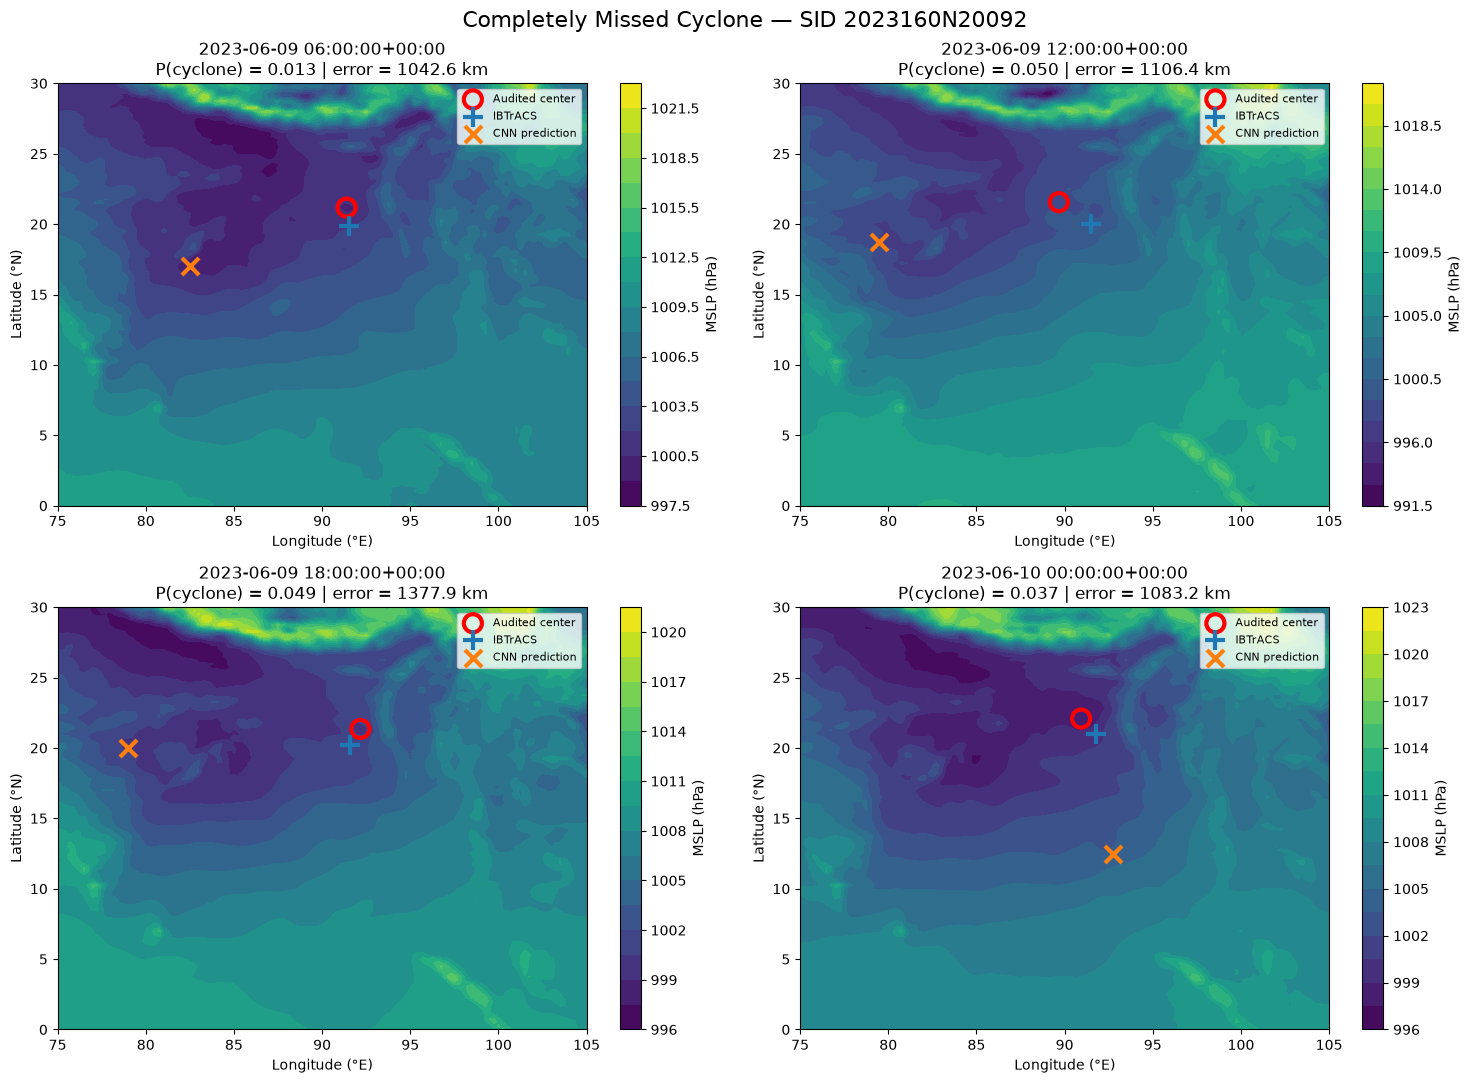

In [ ]:
# ============================================================
# CELL 24C — VISUALIZE COMPLETELY MISSED CYCLONE
# ============================================================

TARGET_SID = "2023160N20092"


storm_cases = (
    target_storm
    .sort_values("timestamp")
    .reset_index(drop=True)
)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 11),
)

axes = axes.ravel()


for ax, (_, case) in zip(
    axes,
    storm_cases.iterrows(),
):

    sample_id = case["sample_id"]

    # --------------------------------------------------------
    # Locate sample in manifest
    # --------------------------------------------------------

    manifest_row = (
        positive_manifest[
            positive_manifest["sample_id"]
            == sample_id
        ]
        .iloc[0]
    )

    array_index = int(
        manifest_row["array_index"]
    )

    # --------------------------------------------------------
    # Retrieve MSLP
    # --------------------------------------------------------

    mslp = np.asarray(
        positive_mslp[
            array_index,
            0
        ]
    )

    # --------------------------------------------------------
    # Centers
    # --------------------------------------------------------

    audited_lat = float(
        manifest_row["center_lat"]
    )

    audited_lon = float(
        manifest_row["center_lon"]
    )

    ib_lat = float(
        manifest_row["ibtracs_lat"]
    )

    ib_lon = float(
        manifest_row["ibtracs_lon"]
    )

    pred_lat = float(
        case["pred_lat"]
    )

    pred_lon = float(
        case["pred_lon"]
    )

    # --------------------------------------------------------
    # Plot MSLP
    # --------------------------------------------------------

    contour = ax.contourf(
        grid_longitude,
        grid_latitude,
        mslp,
        levels=20,
        cmap="viridis",
    )

    plt.colorbar(
        contour,
        ax=ax,
        label="MSLP (hPa)",
    )

    # --------------------------------------------------------
    # Audited cyclone center
    # --------------------------------------------------------

    ax.scatter(
        audited_lon,
        audited_lat,
        s=170,
        facecolors="none",
        edgecolors="red",
        linewidths=3,
        label="Audited center",
        zorder=10,
    )

    # --------------------------------------------------------
    # Original IBTrACS position
    # --------------------------------------------------------

    ax.scatter(
        ib_lon,
        ib_lat,
        marker="+",
        s=190,
        linewidths=3,
        label="IBTrACS",
        zorder=11,
    )

    # --------------------------------------------------------
    # CNN predicted center
    # --------------------------------------------------------

    ax.scatter(
        pred_lon,
        pred_lat,
        marker="x",
        s=150,
        linewidths=3,
        label="CNN prediction",
        zorder=12,
    )

    ax.set_title(
        f"{case['timestamp']}\n"
        f"P(cyclone) = "
        f"{case['presence_probability']:.3f} | "
        f"error = "
        f"{case['localization_error_km']:.1f} km"
    )

    ax.set_xlabel(
        "Longitude (°E)"
    )

    ax.set_ylabel(
        "Latitude (°N)"
    )

    ax.legend(
        fontsize=8,
        loc="best",
    )


fig.suptitle(
    "Completely Missed Cyclone — "
    "SID 2023160N20092",
    fontsize=16,
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 25 — MSLP STRUCTURE OF COMPLETELY MISSED CYCLONE
# ============================================================

rows = []

for _, case in storm_cases.iterrows():

    sample_id = case["sample_id"]

    manifest_row = (
        positive_manifest[
            positive_manifest["sample_id"] == sample_id
        ]
        .iloc[0]
    )

    array_index = int(
        manifest_row["array_index"]
    )

    mslp = np.asarray(
        positive_mslp[array_index, 0]
    )

    # --------------------------------------------------------
    # Global MSLP minimum
    # --------------------------------------------------------

    min_flat = np.nanargmin(mslp)

    min_row, min_col = np.unravel_index(
        min_flat,
        mslp.shape,
    )

    global_min_pressure = float(
        mslp[min_row, min_col]
    )

    global_min_lat = float(
        grid_latitude[min_row]
    )

    global_min_lon = float(
        grid_longitude[min_col]
    )

    # --------------------------------------------------------
    # Grid point nearest audited cyclone center
    # --------------------------------------------------------

    audited_lat = float(
        manifest_row["center_lat"]
    )

    audited_lon = float(
        manifest_row["center_lon"]
    )

    center_row = int(
        np.argmin(
            np.abs(
                grid_latitude - audited_lat
            )
        )
    )

    center_col = int(
        np.argmin(
            np.abs(
                grid_longitude - audited_lon
            )
        )
    )

    center_pressure = float(
        mslp[
            center_row,
            center_col
        ]
    )

    # --------------------------------------------------------
    # Distance: audited center -> global minimum
    # --------------------------------------------------------

    distance_to_global_min = float(
        haversine_km(
            audited_lat,
            audited_lon,
            global_min_lat,
            global_min_lon,
        )
    )

    rows.append(
        {
            "sample_id":
                sample_id,

            "timestamp":
                case["timestamp"],

            "P_cyclone":
                case["presence_probability"],

            "audited_lat":
                audited_lat,

            "audited_lon":
                audited_lon,

            "MSLP_at_audited_center":
                center_pressure,

            "global_min_MSLP":
                global_min_pressure,

            "global_min_lat":
                global_min_lat,

            "global_min_lon":
                global_min_lon,

            "pressure_difference_hPa":
                center_pressure
                - global_min_pressure,

            "distance_to_global_min_km":
                distance_to_global_min,
        }
    )


missed_storm_pressure_analysis = (
    pd.DataFrame(rows)
)


display(
    missed_storm_pressure_analysis.round(2)
)

C:\Users\USER\AppData\Local\Temp\ipykernel_13984\4120816717.py:146: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  missed_storm_pressure_analysis.round(2)


,sample_id,timestamp,P_cyclone,audited_lat,audited_lon,MSLP_at_audited_center,global_min_MSLP,global_min_lat,global_min_lon,pressure_difference_hPa,distance_to_global_min_km
0,sample_002169,2023-06-09 06:00:00+00:00,0.01,21.17,91.39,1000.17,998.06,26.00,86.75,2.12,714.84
1,sample_002170,2023-06-09 12:00:00+00:00,0.05,21.56,89.67,998.45,991.51,29.25,89.00,6.94,857.67
2,sample_002171,2023-06-09 18:00:00+00:00,0.05,21.35,92.17,999.84,996.83,28.50,80.50,3.02,1418.79
3,sample_002172,2023-06-10 00:00:00+00:00,0.04,22.09,90.93,997.92,997.08,25.75,84.00,0.84,813.90


In [ ]:
# ============================================================
# CELL 26 — LOCAL PRESSURE CONTRAST
# ============================================================

contrast_rows = []


for _, case in storm_cases.iterrows():

    sample_id = case["sample_id"]

    manifest_row = (
        positive_manifest[
            positive_manifest["sample_id"] == sample_id
        ]
        .iloc[0]
    )

    array_index = int(
        manifest_row["array_index"]
    )

    mslp = np.asarray(
        positive_mslp[array_index, 0]
    )

    center_lat = float(
        manifest_row["center_lat"]
    )

    center_lon = float(
        manifest_row["center_lon"]
    )

    # --------------------------------------------------------
    # Distance of every grid point from audited center
    # --------------------------------------------------------

    lon_mesh, lat_mesh = np.meshgrid(
        grid_longitude,
        grid_latitude,
    )

    distance = haversine_km(
        center_lat,
        center_lon,
        lat_mesh,
        lon_mesh,
    )

    # --------------------------------------------------------
    # Local cyclone region: <= 250 km
    # Surrounding annulus: 500–1000 km
    # --------------------------------------------------------

    local_mask = (
        distance <= 250
    )

    environment_mask = (
        (distance >= 500)
        &
        (distance <= 1000)
    )

    local_min = float(
        np.nanmin(
            mslp[local_mask]
        )
    )

    environment_mean = float(
        np.nanmean(
            mslp[environment_mask]
        )
    )

    contrast_rows.append(
        {
            "sample_id":
                sample_id,

            "timestamp":
                case["timestamp"],

            "P_cyclone":
                case["presence_probability"],

            "local_min_MSLP":
                local_min,

            "environment_mean_MSLP":
                environment_mean,

            "local_pressure_deficit_hPa":
                environment_mean
                - local_min,
        }
    )


local_contrast = pd.DataFrame(
    contrast_rows
)


display(
    local_contrast.round(2)
)

C:\Users\USER\AppData\Local\Temp\ipykernel_13984\3389620863.py:113: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  local_contrast.round(2)


,sample_id,timestamp,P_cyclone,local_min_MSLP,environment_mean_MSLP,local_pressure_deficit_hPa
0,sample_002169,2023-06-09 06:00:00+00:00,0.01,1000.06,1004.16,4.10
1,sample_002170,2023-06-09 12:00:00+00:00,0.05,996.86,1001.27,4.41
2,sample_002171,2023-06-09 18:00:00+00:00,0.05,999.75,1004.57,4.83
3,sample_002172,2023-06-10 00:00:00+00:00,0.04,997.92,1003.84,5.92


In [ ]:
# ============================================================
# CELL 27 — LOCAL PRESSURE CONTRAST FOR POSITIVE TEST FRAMES
# ============================================================

positive_cases = (
    positive_test_predictions
    .copy()
    .reset_index(drop=True)
)

contrast_rows = []


lon_mesh, lat_mesh = np.meshgrid(
    grid_longitude,
    grid_latitude,
)


for _, case in positive_cases.iterrows():

    sample_id = case["sample_id"]

    manifest_row = (
        positive_manifest[
            positive_manifest["sample_id"]
            == sample_id
        ]
        .iloc[0]
    )

    array_index = int(
        manifest_row["array_index"]
    )

    mslp = np.asarray(
        positive_mslp[array_index, 0]
    )

    center_lat = float(
        manifest_row["center_lat"]
    )

    center_lon = float(
        manifest_row["center_lon"]
    )

    # --------------------------------------------------------
    # Distance grid
    # --------------------------------------------------------

    distance = haversine_km(
        center_lat,
        center_lon,
        lat_mesh,
        lon_mesh,
    )

    local_mask = (
        distance <= 250
    )

    environment_mask = (
        (distance >= 500)
        &
        (distance <= 1000)
    )

    local_min = float(
        np.nanmin(
            mslp[local_mask]
        )
    )

    environment_mean = float(
        np.nanmean(
            mslp[environment_mask]
        )
    )

    deficit = (
        environment_mean
        - local_min
    )

    contrast_rows.append(
        {
            "sample_id":
                sample_id,

            "sid":
                case["sid"],

            "timestamp":
                case["timestamp"],

            "presence_probability":
                case["presence_probability"],

            "predicted_presence":
                int(case["predicted_presence"]),

            "local_min_MSLP":
                local_min,

            "environment_mean_MSLP":
                environment_mean,

            "local_pressure_deficit_hPa":
                deficit,
        }
    )


positive_pressure_contrast = pd.DataFrame(
    contrast_rows
)


print("=" * 72)
print("POSITIVE TEST-FRAME PRESSURE CONTRAST")
print("=" * 72)

print(
    "Frames:",
    len(positive_pressure_contrast)
)

print()

display(
    positive_pressure_contrast[
        "local_pressure_deficit_hPa"
    ].describe()
)

POSITIVE TEST-FRAME PRESSURE CONTRAST
Frames: 341



count    341.000000
mean      10.190572
std        6.841762
min        1.726562
25%        5.653198
50%        8.403259
75%       12.808105
max       47.044128
Name: local_pressure_deficit_hPa, dtype: float64

In [35]:
# ============================================================
# CELL 28 — PRESSURE CONTRAST: DETECTED VS MISSED
# ============================================================

contrast_comparison = (
    positive_pressure_contrast
    .groupby(
        "predicted_presence"
    )
    ["local_pressure_deficit_hPa"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max",
        ]
    )
    .reset_index()
)


contrast_comparison[
    "group"
] = contrast_comparison[
    "predicted_presence"
].map(
    {
        0: "Missed cyclone",
        1: "Detected cyclone",
    }
)


display(
    contrast_comparison[
        [
            "group",
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max",
        ]
    ].round(2)
)

,group,count,mean,median,std,min,max
0,Missed cyclone,20,4.61,3.38,2.90,1.73,11.80
1,Detected cyclone,321,10.54,8.65,6.87,1.97,47.04


In [36]:
# ============================================================
# CELL 29 — TARGET STORM VS TEST DISTRIBUTION
# ============================================================

target_contrast = (
    positive_pressure_contrast[
        positive_pressure_contrast["sid"]
        == TARGET_SID
    ]
)


overall_detected = (
    positive_pressure_contrast[
        positive_pressure_contrast[
            "predicted_presence"
        ] == 1
    ][
        "local_pressure_deficit_hPa"
    ]
)


print("=" * 72)
print("TARGET CYCLONE PRESSURE-CONTRAST COMPARISON")
print("=" * 72)

print(
    "Target SID:",
    TARGET_SID
)

print(
    "Target mean deficit:",
    f"{target_contrast['local_pressure_deficit_hPa'].mean():.2f} hPa"
)

print(
    "Target range:",
    f"{target_contrast['local_pressure_deficit_hPa'].min():.2f}",
    "to",
    f"{target_contrast['local_pressure_deficit_hPa'].max():.2f}",
    "hPa",
)

print()

print(
    "Detected-frame median:",
    f"{overall_detected.median():.2f} hPa"
)

print(
    "Detected-frame 25th percentile:",
    f"{overall_detected.quantile(0.25):.2f} hPa"
)

print(
    "Detected-frame 10th percentile:",
    f"{overall_detected.quantile(0.10):.2f} hPa"
)

TARGET CYCLONE PRESSURE-CONTRAST COMPARISON
Target SID: 2023160N20092
Target mean deficit: 4.81 hPa
Target range: 4.10 to 5.92 hPa

Detected-frame median: 8.65 hPa
Detected-frame 25th percentile: 5.89 hPa
Detected-frame 10th percentile: 4.41 hPa


# Experiment 03 — Cyclone Presence Detection and Center Localization

## Objective

Experiment 03 extends the previous center-localization experiments by introducing **negative ERA5 frames**. The model must therefore solve two tasks simultaneously:

1. **Cyclone presence detection** — determine whether a cyclone exists in the regional frame.
2. **Center localization** — estimate the cyclone center when a cyclone is present.

The experiment uses the regional domain **0–30°N, 75–105°E** on a **121 × 121** grid.

---

## Dataset

The dataset contains:

- **1,900 positive cyclone frames**
- **1,900 negative non-cyclone frames**
- Input variable: **MSLP only**
- Positive center labels: **audited cyclone centers**
- Positive and negative samples use consistent train/validation/test splits.

The negative samples were selected from available ERA5 timestamps outside known cyclone periods and materialized separately.

The test set contains:

- 341 positive frames
- 341 negative frames
- **682 total test samples**

---

## Model Architecture

Experiment 03 uses a **multi-task CNN** with a shared spatial encoder and two output tasks:

**Input**

`MSLP (1 × 121 × 121)`

**Shared CNN encoder**

Extracts spatial pressure features from the regional MSLP field.

**Presence head**

Predicts the probability that a cyclone is present:

`P(cyclone)`

**Localization head**

Predicts a spatial heatmap representing the cyclone center.

Conceptually:

`MSLP → Shared CNN Encoder → {Presence Head, Center Heatmap Head}`

Localization supervision is applied to positive cyclone samples, while presence classification is trained using both positive and negative samples.

Learning-rate reduction and early stopping were used during training.

---

## Best Validation Checkpoint

The best checkpoint occurred at **Epoch 11** with a validation score of **0.8695**.

### Presence Detection

| Metric | Value |
|---|---:|
| Accuracy | 96.41% |
| Precision | 96.83% |
| Recall | 95.96% |
| F1 | 96.40% |

### Localization

| Metric | Value |
|---|---:|
| Mean error | 37.41 km |
| Median error | 15.93 km |
| Within 25 km | 75.8% |
| Within 50 km | 91.9% |
| Within 100 km | 96.0% |

Training stopped after 36 epochs due to early stopping.

---

## Final Test Results

### Presence Detection

| Metric | Value |
|---|---:|
| Accuracy | **94.13%** |
| Precision | **94.13%** |
| Recall | **94.13%** |
| F1 | **94.13%** |

Confusion counts:

- True positives: **321**
- True negatives: **321**
- False positives: **20**
- False negatives: **20**

The model detected **321/341 cyclone frames**, corresponding to a detection rate of **94.1%**.

### Localization on All True Cyclone Frames

| Metric | Value |
|---|---:|
| Mean error | 43.19 km |
| Median error | 19.03 km |
| Within 25 km | 64.8% |
| Within 50 km | 90.3% |
| Within 100 km | 95.3% |

### End-to-End Localization Among Detected Cyclones

When localization is evaluated only for the **321 successfully detected cyclone frames**:

| Metric | Value |
|---|---:|
| Mean error | **25.22 km** |
| Median error | **18.57 km** |
| Within 25 km | **67.0%** |
| Within 50 km | **92.2%** |
| Within 100 km | **97.5%** |

This shows that localization is generally accurate once the cyclone has been successfully detected.

---

## Error Analysis

### False Negatives

The test set contains **20 false-negative frames** belonging to **10 unique cyclones**.

Most affected cyclones were only partially missed. However, cyclone **SID 2023160N20092** was completely missed in all four of its test frames.

Its predicted cyclone probabilities were approximately:

`0.013, 0.050, 0.049, 0.037`

indicating a systematic failure rather than a borderline classification error.

---

## Relationship Between MSLP Contrast and Missed Detection

To investigate the false negatives, a local pressure-deficit metric was calculated:

`Local pressure deficit = environmental mean MSLP − local minimum MSLP`

where:

- local region: within 250 km of the audited center
- environmental region: 500–1000 km from the audited center

Across all **341 positive test frames**:

- Mean deficit: **10.19 hPa**
- Median deficit: **8.40 hPa**
- 25th percentile: **5.65 hPa**
- 75th percentile: **12.81 hPa**

A clear difference was observed between detected and missed cyclone frames:

| Group | Frames | Mean Deficit | Median Deficit |
|---|---:|---:|---:|
| Missed | 20 | **4.61 hPa** | **3.38 hPa** |
| Detected | 321 | **10.54 hPa** | **8.65 hPa** |

Therefore, **weak local MSLP contrast is strongly associated with false-negative detection**.

However, the distributions overlap, so MSLP contrast alone does not fully explain detection success or failure.

---

## Completely Missed Cyclone Case

For **SID 2023160N20092**, the four analyzed frames had local pressure deficits of:

`4.10, 4.41, 4.83, 5.92 hPa`

with a mean of **4.81 hPa**.

For comparison:

- Detected-frame median: **8.65 hPa**
- Detected-frame 25th percentile: **5.89 hPa**
- Detected-frame 10th percentile: **4.41 hPa**

This cyclone therefore lies toward the **weak-pressure-signature region** of the test distribution.

Visual analysis also showed a broad competing low-pressure structure elsewhere in the regional MSLP field. This makes the target cyclone relatively difficult to distinguish using MSLP alone.

---

## False-Positive Analysis

There were **20 false positives**.

Their predicted cyclone probabilities were relatively high:

- Mean probability: **0.774**
- Median probability: **0.800**
- Maximum probability: **0.981**

Temporal comparison with IBTrACS showed:

- 30% were within 48 h of an IBTrACS observation
- 40% were within 72 h
- 75% were within 120 h

However, spatial comparison showed:

- 0% within 100 km of the associated track
- 15% within 200 km
- 25% within 300 km
- 50% within 500 km

Only **3/20 (15%)** satisfied both:

`within ±120 h AND within 300 km`

Therefore, most false positives cannot simply be explained as mislabeled cyclone frames.

One high-confidence false positive (`negative_000113`, P(cyclone) ≈ 0.981) showed an organized low-pressure system before its later IBTrACS entry, suggesting that some apparent false positives may correspond to **pre-IBTrACS developing disturbances**.

---

## Main Conclusion

Experiment 03 demonstrates that an **MSLP-only multi-task CNN** can achieve strong cyclone presence detection and center localization performance. The main identified weakness is reduced detection performance for cyclone frames with weak local pressure contrast. False-positive analysis also indicates that some nominally negative frames can contain organized low-pressure disturbances, highlighting limitations of binary labels based solely on best-track timing.
